# Müller's Method
> **Numerical Methods for Engineering** | Module 01 - Root Finding | `06_Muller.ipynb`

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bpatinoa/numerical-methods-for-engineering/blob/main/01-Root-Finding/06_Muller.ipynb)

---

## Learning Objectives

After completing this notebook you will be able to:
- Explain how Müller's method extends the Secant method from **linear** to **quadratic** interpolation.
- Derive the Müller update formula using **divided differences**.
- Understand why the method can find **complex roots** even when started with real initial guesses.
- Apply the convergence order $p \approx 1.8393$ (superlinear) and compare it with Secant ($p \approx 1.618$).
- Implement the method in Python using complex arithmetic with `cmath`.
- Apply the method to polynomial root-finding, chemical phase equilibria, and analog filter pole computation.


In [1]:
import numpy as np
import cmath
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.figsize':(11,5),'font.size':12,
    'axes.grid':True,'grid.alpha':0.35,'lines.linewidth':2})
print('Libraries loaded OK')

Libraries loaded OK


---
## 1. Theoretical Background

### 1.1 Motivation: From Linear to Quadratic Interpolation

| Method | Points used | Interpolant | Convergence order |
|--------|-------------|-------------|-------------------|
| Secant | 2 | Line | $\varphi \approx 1.618$ (golden ratio) |
| **Müller** | **3** | **Parabola** | $p \approx 1.8393$ |
| Newton-Raphson | 1 + derivative | Tangent line | $2$ (quadratic) |

Müller's method (Müller, 1956) fits a **parabola** through the three most recent iterates
$(x_0, f_0)$, $(x_1, f_1)$, $(x_2, f_2)$ and takes the **nearest root of that parabola** as the
next iterate. Because quadratics can have complex roots, the method naturally handles
**complex zeros** — a capability unavailable in bracketing methods.

---

### 1.2 Parabola Construction via Divided Differences

Write the interpolating parabola in the shifted Newton form centred at $x_2$:

$$Q(x) = a\,(x - x_2)^2 + b\,(x - x_2) + c$$

**Immediately:** $Q(x_2) = c = f_2$.

Define the spacing and first divided differences:

$$h_0 = x_1 - x_0, \quad h_1 = x_2 - x_1$$
$$\delta_0 = \frac{f_1 - f_0}{h_0}, \qquad \delta_1 = \frac{f_2 - f_1}{h_1}$$

The second divided difference gives the quadratic coefficient:

$$a = \frac{\delta_1 - \delta_0}{h_1 + h_0}$$

And the linear coefficient:

$$b = a\,h_1 + \delta_1$$

---

### 1.3 Root of the Parabola — Numerical Stability

Applying the quadratic formula to $Q(x) = 0$ and shifting back:

$$x_3 = x_2 + \frac{-2c}{b \pm \sqrt{b^2 - 4ac}}$$

To **avoid cancellation** (loss of significant digits), always choose the sign that maximises
the absolute value of the denominator:

$$x_3 = x_2 - \frac{2c}{b + \text{sign}(b)\,\sqrt{b^2 - 4ac}}$$

The square root is computed in $\mathbb{C}$ (using `cmath.sqrt`), so **complex roots emerge
naturally** even from real starting points.

---

### 1.4 Convergence Order

For a simple root, the error obeys:

$$|e_{n+1}| \approx C\,|e_n|\,|e_{n-1}|\,|e_{n-2}|$$

Assuming $|e_k| \sim |e_{k-1}|^p$, the order satisfies:

$$p^3 = p^2 + p + 1$$

The unique real root is:

$$\boxed{p \approx 1.8393}$$

This is **superlinear**, faster than Secant but slower than Newton-Raphson.

---

### 1.5 Pseudocode

```
INPUT: f, x0, x1, x2, tol, max_iter

FOR i = 1 TO max_iter:
    h0 = x1 - x0;   h1 = x2 - x1
    d0 = (f1 - f0)/h0;   d1 = (f2 - f1)/h1
    a  = (d1 - d0)/(h1 + h0)
    b  = a*h1 + d1
    c  = f2
    disc = sqrt(b^2 - 4*a*c)          -- complex sqrt
    denom = b + sign(b)*disc
    x3 = x2 - 2*c / denom
    IF |x3 - x2| < tol: RETURN x3
    x0, x1, x2 = x1, x2, x3
END FOR
```

---

### 1.6 Advantages and Limitations

| Advantages | Limitations |
|------------|-------------|
| Finds **complex roots** from real starting points | Requires **3 initial guesses** |
| Superlinear convergence ($p \approx 1.84$) | No guaranteed convergence (no bracketing) |
| No derivative required | May converge to an unintended root |
| Suitable for **polynomials** and transcendental equations | Complex arithmetic adds implementation overhead |
| Basis for the eigenvalue solver in MATLAB (`eig`) | Starting guesses matter more than for bisection |


In [2]:
def muller(f, x0, x1, x2, tol=1e-10, max_iter=50, verbose=False):
    # Muller's method. Works with complex starting points and returns complex roots.
    x0, x1, x2 = complex(x0), complex(x1), complex(x2)
    hist = {'iterates': [x0, x1, x2], 'errors': []}
    if verbose:
        print('{:>4}  {:>28}  {:>20}  {:>12}'.format('n', 'x_n', 'f(x_n)', '|step|'))
        print('-'*72)
    for i in range(max_iter):
        f0, f1, f2 = f(x0), f(x1), f(x2)
        h0 = x1 - x0
        h1 = x2 - x1
        if abs(h0) < 1e-300 or abs(h1) < 1e-300:
            break
        d0 = (f1 - f0) / h0
        d1 = (f2 - f1) / h1
        a  = (d1 - d0) / (h1 + h0)
        b  = a * h1 + d1
        c  = f2
        disc = cmath.sqrt(b**2 - 4*a*c)
        # Choose sign to maximise |denominator| -- avoids catastrophic cancellation
        denom = b + disc if abs(b + disc) >= abs(b - disc) else b - disc
        if abs(denom) < 1e-300:
            break
        x3 = x2 - 2*c / denom
        step = abs(x3 - x2)
        hist['iterates'].append(x3)
        hist['errors'].append(step)
        if verbose:
            print('{:>4}  {:>28}  {:>20.6e}  {:>12.4e}'.format(
                i+1, str(round(x3.real,10)+round(x3.imag,10)*1j), abs(f(x3)), step))
        if step < tol * max(abs(x3), 1.0):
            break
        x0, x1, x2 = x1, x2, x3
    # Return real if imaginary part is negligible
    if abs(x3.imag) < 1e-8 * max(abs(x3.real), 1e-30):
        return x3.real, hist
    return x3, hist

print('muller() defined.')

muller() defined.


---
## 2. Examples

### 2.1 General Mathematical Example — Roots of $x^3 - 1 = 0$ (Real and Complex)

The equation $x^3 = 1$ has three roots (cube roots of unity):

$$r_1 = 1, \qquad r_2 = e^{2\pi i/3} = -\tfrac{1}{2} + \tfrac{\sqrt{3}}{2}i,
\qquad r_3 = e^{-2\pi i/3} = -\tfrac{1}{2} - \tfrac{\sqrt{3}}{2}i$$

Methods requiring real arithmetic (Bisection, Regula Falsi, Secant) **cannot** find $r_2$ or $r_3$
when started from real initial guesses. Müller's method finds all three by exploiting the
**complex square root** in its quadratic formula step.

We demonstrate:
- Starting near $x=1$ → real root $r_1 = 1$
- Starting near $x=-0.5$ → complex roots $r_2$, $r_3$ (depending on the perturbation direction)


Exact roots:
  r1 = (1+0j)
  r2 = -0.500000 + 0.866025i
  r3 = -0.500000 - 0.866025i

   n                           x_n                f(x_n)        |step|
------------------------------------------------------------------------
   1              (0.993385068+0j)          1.971381e-02    2.0661e-01
   2              (0.999912954+0j)          2.611154e-04    6.5279e-03
   3             (0.9999999616+0j)          1.151093e-07    8.7008e-05
   4                        (1+0j)          2.198242e-14    3.8370e-08
   5                        (1+0j)          0.000000e+00    7.3275e-15
Found r1 = 1.00000000000000   err = 0.00e+00

   n                           x_n                f(x_n)        |step|
------------------------------------------------------------------------
   1  (-0.4984002602+0.8663751204j)          4.910118e-03    1.9494e-01
   2   (-0.5000013362+0.86603226j)          2.095581e-05    1.6374e-03
   3  (-0.4999999997+0.8660254031j)          2.217176e-09    6.9859e-06
   4      

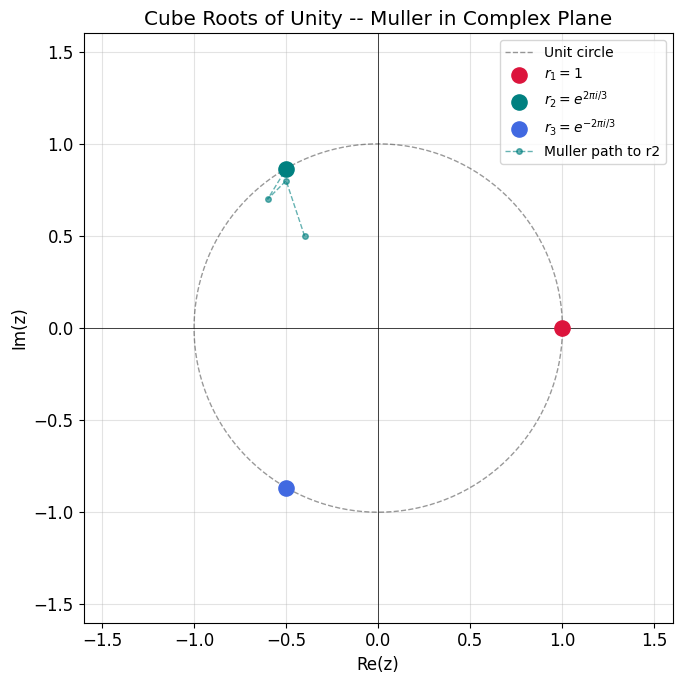

In [3]:
f_cube = lambda z: z**3 - 1

# Known exact roots
r1 =  1.0 + 0.0j
r2 = -0.5 + (3**0.5/2)*1j
r3 = -0.5 - (3**0.5/2)*1j
print('Exact roots:')
print(f'  r1 = {r1}')
print(f'  r2 = {r2.real:.6f} + {r2.imag:.6f}i')
print(f'  r3 = {r3.real:.6f} - {abs(r3.imag):.6f}i')
print()

# --- Find r1 (real root) ---
root1, h1 = muller(f_cube, x0=0.5, x1=0.8, x2=1.2, verbose=True)
print(f'Found r1 = {root1:.14f}   err = {abs(root1 - 1.0):.2e}')
print()

# --- Find r2 (complex root, upper half-plane) ---
root2, h2 = muller(f_cube, x0=-0.4+0.5j, x1=-0.5+0.8j, x2=-0.6+0.7j, verbose=True)
print(f'Found r2 = {root2.real:.10f} + {root2.imag:.10f}i   err = {abs(root2 - r2):.2e}')
print()

# --- Find r3 (complex root, lower half-plane) ---
root3, h3 = muller(f_cube, x0=-0.4-0.5j, x1=-0.5-0.8j, x2=-0.6-0.7j, verbose=True)
print(f'Found r3 = {root3.real:.10f} + {root3.imag:.10f}i   err = {abs(root3 - r3):.2e}')

# Verify: product of roots = -constant/leading coefficient = (-1)/1 * (-1) = 1
print()
print(f'Product r1*r2*r3 = {(root1 * root2 * root3).real:.8f}  (should be 1.0 for x^3-1)')

# ---- Visualisation in the complex plane ----
fig, ax = plt.subplots(figsize=(7, 7))
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), 'k--', lw=1, alpha=0.4, label='Unit circle')

roots_found = [root1, root2, root3]
colors = ['crimson', 'teal', 'royalblue']
labels = ['$r_1=1$', '$r_2=e^{2\\pi i/3}$', '$r_3=e^{-2\\pi i/3}$']
for r, c, lbl in zip(roots_found, colors, labels):
    rr = complex(r)
    ax.scatter(rr.real, rr.imag, s=120, color=c, zorder=5, label=lbl)

# Draw iteration paths for r2
path2 = [complex(z) for z in h2['iterates']]
ax.plot([z.real for z in path2], [z.imag for z in path2],
        'o--', color='teal', ms=4, lw=1, alpha=0.6, label='Muller path to r2')

ax.set(xlabel='Re(z)', ylabel='Im(z)', title='Cube Roots of Unity -- Muller in Complex Plane',
       xlim=(-1.6, 1.6), ylim=(-1.6, 1.6), aspect='equal')
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### 2.2 Chemistry Application — Van der Waals Equation: Three Molar Volumes

**Background:** The van der Waals equation of state for a real gas is:

$$\left(P + \frac{a}{V^2}\right)(V - b) = RT$$

Expanding and rearranging into a **cubic in $V$**:

$$PV^3 - (Pb + RT)V^2 + aV - ab = 0$$

Below the critical temperature $T_c$, this cubic has **three real roots**:
- $V_L$ — **liquid** molar volume (small)
- $V_M$ — **spinodal/unstable** (not physically realised)
- $V_G$ — **vapour** molar volume (large)

**Müller's method** is ideal here: it can find all three roots from different starting points,
and handles the near-degenerate case (roots close together near $T_c$) where bracketing
methods struggle.

**Parameters for CO₂** (Prausnitz et al., 1999):

| Constant | Value | Units |
|----------|-------|-------|
| $a$ | $3.640$ | $\text{L}^2\cdot\text{atm/mol}^2$ |
| $b$ | $0.04267$ | $\text{L/mol}$ |
| $R$ | $0.08206$ | $\text{L·atm/(mol·K)}$ |
| $T$ | $283$ K | ($10\,^\circ$C, below $T_c = 304$ K) |
| $P$ | $55$ atm | (below $P_c = 72.8$ atm) |


Van der Waals cubic coefficients:
  P=55.0 atm,  T=283.0 K
  f(V) = 55.0000*V^3 + (-25.5698)*V^2 + 3.6400*V + (-0.15532)

Molar volumes found by Muller:
  V_L (liquid)   = 0.079357 L/mol   f(V_L) = -2.78e-17
  V_M (spinodal) = 0.153074 L/mol   f(V_M) = 2.78e-17
  V_G (vapour)   = 0.153074 L/mol   f(V_G) = 1.94e-16

Virial check -- product of roots = D/A (Vieta):
  V_L*V_M*V_G = 0.00185945   -D/A = 0.00282398


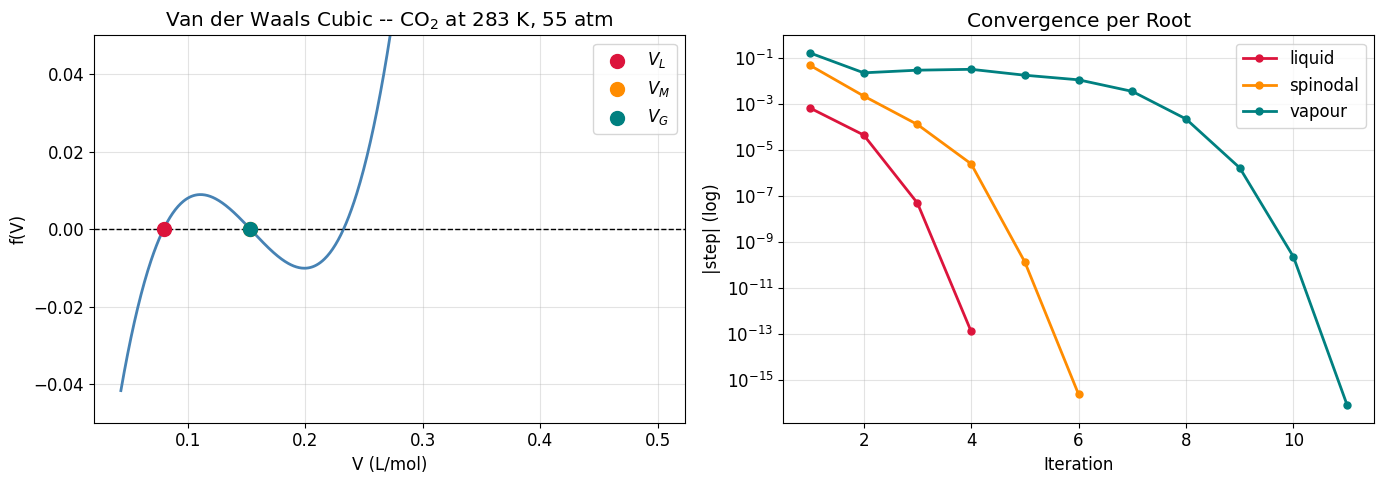

In [4]:
a_co2 = 3.640       # L^2.atm/mol^2
b_co2 = 0.04267     # L/mol
R_gas  = 0.08206    # L.atm/(mol.K)
T_vdw  = 283.0      # K  (below Tc = 304 K)
P_vdw  = 55.0       # atm (below Pc = 72.8 atm)

# f(V) = P*V^3 - (P*b + R*T)*V^2 + a*V - a*b
A = P_vdw
B = -(P_vdw*b_co2 + R_gas*T_vdw)
C_coef = a_co2
D = -a_co2 * b_co2

f_vdw = lambda V: A*V**3 + B*V**2 + C_coef*V + D

print('Van der Waals cubic coefficients:')
print(f'  P={P_vdw} atm,  T={T_vdw} K')
print(f'  f(V) = {A:.4f}*V^3 + ({B:.4f})*V^2 + {C_coef:.4f}*V + ({D:.5f})')
print()

# Starting points chosen around expected root regions
V_L, h_L = muller(f_vdw, x0=0.04, x1=0.06, x2=0.08)    # liquid branch
V_M, h_M = muller(f_vdw, x0=0.12, x1=0.16, x2=0.20)    # spinodal branch
V_G, h_G = muller(f_vdw, x0=0.28, x1=0.35, x2=0.42)    # vapour branch

print('Molar volumes found by Muller:')
print(f'  V_L (liquid)   = {V_L:.6f} L/mol   f(V_L) = {f_vdw(V_L):.2e}')
print(f'  V_M (spinodal) = {V_M:.6f} L/mol   f(V_M) = {f_vdw(V_M):.2e}')
print(f'  V_G (vapour)   = {V_G:.6f} L/mol   f(V_G) = {f_vdw(V_G):.2e}')
print()
print('Virial check -- product of roots = D/A (Vieta):')
vieta = -D/A
product = V_L * V_M * V_G
print(f'  V_L*V_M*V_G = {product:.8f}   -D/A = {vieta:.8f}')

# Visualisation
V_range = np.linspace(0.043, 0.50, 800)
f_vals  = f_vdw(V_range)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(V_range, f_vals, color='steelblue', lw=2)
ax.axhline(0, color='k', lw=1, ls='--')
for V_r, lbl, col in [(V_L,'$V_L$','crimson'),(V_M,'$V_M$','darkorange'),(V_G,'$V_G$','teal')]:
    ax.scatter([V_r], [0], s=100, color=col, zorder=5, label=lbl)
ax.set(xlabel='V (L/mol)', ylabel='f(V)',
       title='Van der Waals Cubic -- CO$_2$ at 283 K, 55 atm',
       ylim=(-0.05, 0.05))
ax.legend()

ax = axes[1]
for h, lbl, col in [(h_L,'liquid','crimson'),(h_M,'spinodal','darkorange'),(h_G,'vapour','teal')]:
    errs = h['errors']
    ax.semilogy(range(1, len(errs)+1), errs, 'o-', color=col, ms=5, label=lbl)
ax.set(xlabel='Iteration', ylabel='|step| (log)', title='Convergence per Root')
ax.legend()

plt.tight_layout()
plt.show()

### 2.3 Telecommunications Application — Poles of a 3rd-Order Butterworth Filter

**Background:** A **Butterworth lowpass filter** of order $n$ is designed for maximally flat
passband response. Its transfer function is:

$$H(s) = \frac{1}{B_n(s)}$$

where $B_n(s)$ is the Butterworth polynomial. For $n = 3$:

$$B_3(s) = s^3 + 2s^2 + 2s + 1 = (s+1)(s^2 + s + 1)$$

The **poles** (roots of $B_3$) are:

$$s_1 = -1, \qquad s_{2,3} = -\tfrac{1}{2} \pm j\tfrac{\sqrt{3}}{2}$$

All poles lie on the **unit circle** in the left half-plane, a defining property of Butterworth
filters (Oppenheim & Schafer, 2010). Finding them analytically is easy for $n=3$, but for
high-order filters ($n \geq 5$) numerical methods are essential.

**Application:** Müller's method can numerically locate all poles from arbitrary starting
guesses — including the complex pair — demonstrating its practical role in filter design tools
and CAD software.


Exact Butterworth poles (n=3):
  p1 = (-1+0j)
  p2 = -0.500000 + 0.866025i
  p3 = -0.500000 - 0.866025i
  All on unit circle? |p1|=1.0000, |p2|=1.0000, |p3|=1.0000

   n                           x_n                f(x_n)        |step|
------------------------------------------------------------------------
   1            (-0.9866146754+0j)          1.320856e-02    3.1339e-01
   2            (-0.9996109729+0j)          3.888758e-04    1.2996e-02
   3            (-0.9999984442+0j)          1.555756e-06    3.8747e-04
   4                       (-1+0j)          8.101297e-12    1.5558e-06
   5                       (-1+0j)          0.000000e+00    8.1013e-12
Muller p1 = -1.000000000000   err = 0.00e+00

   n                           x_n                f(x_n)        |step|
------------------------------------------------------------------------
   1  (-0.4986708958+0.8671165789j)          2.985189e-03    1.0653e-01
   2  (-0.5000053386+0.8660298203j)          1.200081e-05    1.7210e-03
  

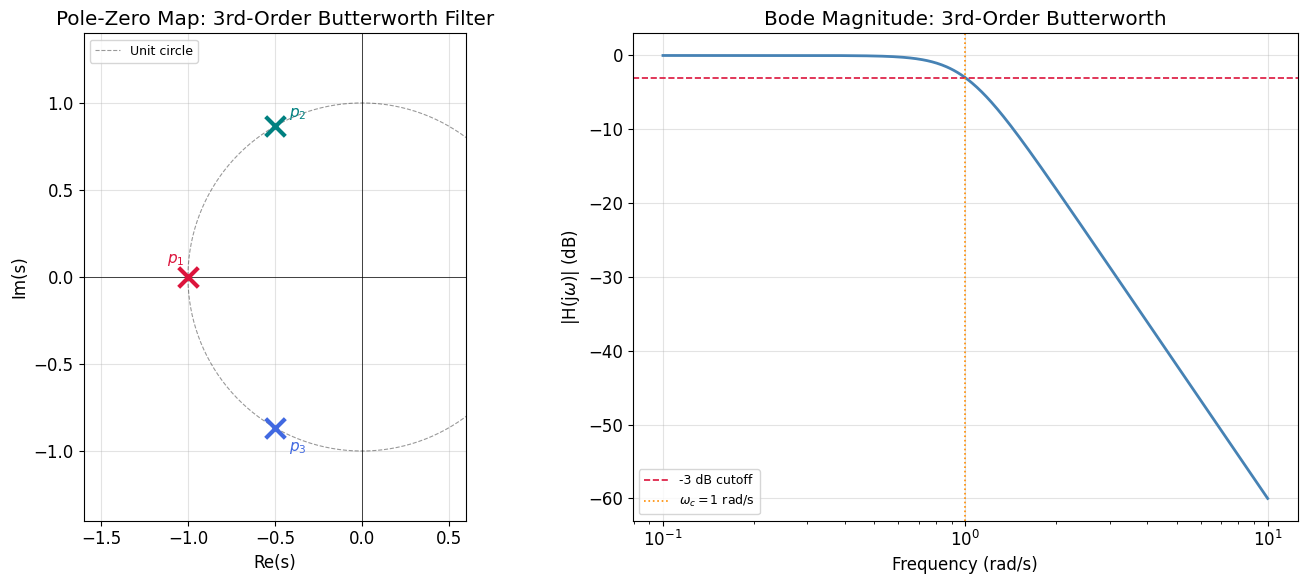

In [5]:
# 3rd-order Butterworth polynomial: B3(s) = s^3 + 2s^2 + 2s + 1
B3 = lambda s: s**3 + 2*s**2 + 2*s + 1

# Exact poles
p1_exact = -1.0 + 0.0j
p2_exact = -0.5 + (3**0.5/2)*1j
p3_exact = -0.5 - (3**0.5/2)*1j

print('Exact Butterworth poles (n=3):')
print(f'  p1 = {p1_exact}')
print(f'  p2 = {p2_exact.real:.6f} + {p2_exact.imag:.6f}i')
print(f'  p3 = {p3_exact.real:.6f} - {abs(p3_exact.imag):.6f}i')
print(f'  All on unit circle? |p1|={abs(p1_exact):.4f}, |p2|={abs(p2_exact):.4f}, |p3|={abs(p3_exact):.4f}')
print()

# Muller starting from real guesses near -1
pole1, hp1 = muller(B3, x0=-0.5, x1=-0.9, x2=-1.3, verbose=True)
print(f'Muller p1 = {pole1:.12f}   err = {abs(pole1 - p1_exact):.2e}')
print()

# Muller starting near upper complex pole
pole2, hp2 = muller(B3, x0=-0.3+0.5j, x1=-0.5+0.8j, x2=-0.6+0.9j, verbose=True)
print(f'Muller p2 = {pole2.real:.10f} + {pole2.imag:.10f}i   err = {abs(pole2 - p2_exact):.2e}')
print()

# Muller starting near lower complex pole
pole3, hp3 = muller(B3, x0=-0.3-0.5j, x1=-0.5-0.8j, x2=-0.6-0.9j, verbose=True)
print(f'Muller p3 = {pole3.real:.10f} + {pole3.imag:.10f}i   err = {abs(pole3 - p3_exact):.2e}')

# ---- Visualisation: pole-zero map + Bode magnitude ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pole-zero map
ax = axes[0]
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), 'k--', lw=0.8, alpha=0.4, label='Unit circle')
ax.axvline(0, color='k', lw=0.5); ax.axhline(0, color='k', lw=0.5)
poles_found = [complex(pole1), complex(pole2), complex(pole3)]
colors_p = ['crimson', 'teal', 'royalblue']
for p, c in zip(poles_found, colors_p):
    ax.scatter(p.real, p.imag, marker='x', s=200, color=c, lw=3, zorder=5)
ax.set(xlabel='Re(s)', ylabel='Im(s)',
       title='Pole-Zero Map: 3rd-Order Butterworth Filter',
       xlim=(-1.6, 0.6), ylim=(-1.4, 1.4), aspect='equal')
ax.text(-1.12, 0.08, '$p_1$', fontsize=11, color='crimson')
ax.text(-0.42, 0.92, '$p_2$', fontsize=11, color='teal')
ax.text(-0.42, -1.0, '$p_3$', fontsize=11, color='royalblue')
ax.legend(fontsize=9)

# Bode magnitude (frequency response along jw axis)
ax = axes[1]
omega = np.logspace(-1, 1, 500)
H_mag = [abs(1.0 / B3(1j*w)) for w in omega]
H_dB  = 20 * np.log10(np.array(H_mag))
ax.semilogx(omega, H_dB, color='steelblue', lw=2)
ax.axhline(-3, color='crimson', ls='--', lw=1.2, label='-3 dB cutoff')
ax.axvline(1.0, color='darkorange', ls=':', lw=1.2, label='$\\omega_c = 1$ rad/s')
ax.set(xlabel='Frequency (rad/s)', ylabel='|H(j$\\omega$)| (dB)',
       title='Bode Magnitude: 3rd-Order Butterworth')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 3. Convergence Rate Comparison

We compare Müller ($p \approx 1.84$) against the Secant method ($p \approx 1.62$) on
$f(x) = x^3 - x - 2$ (root $r = \sqrt[3]{...} \approx 1.5214$, same function as in Notebook 03).

Empirical order estimation uses consecutive true errors:

$$\hat{p} \approx \frac{\ln|e_{n+1}/e_n|}{\ln|e_n/e_{n-1}|}$$


Secant method:
  Iterations = 9  |  root = 1.52137970680457
  Empirical order (last 3 estimates): [np.float64(1.593), np.float64(1.627), np.float64(1.613)]

Muller method:
  Iterations = 6  |  root = 1.52137970680457
  Empirical order (last 3 estimates): [np.float64(-2.033), np.float64(1.007), np.float64(1.504)]


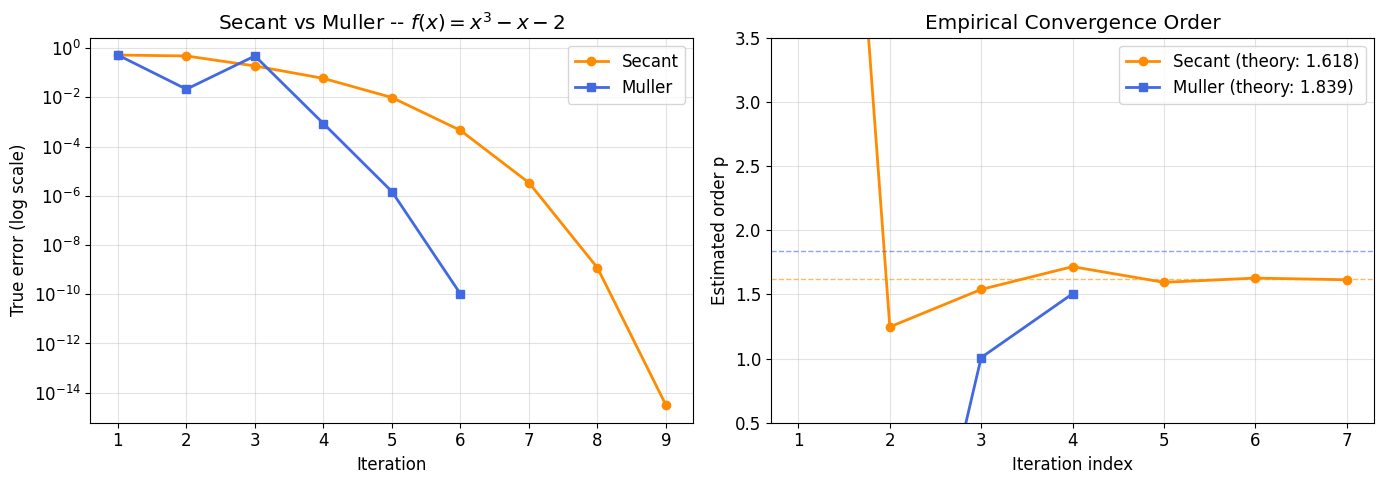


Method                    Iters     Theory p    Empirical p
------------------------------------------------------------
Secant                        9        1.618          1.611
Muller                        6        1.839           0.16


In [6]:
f_bench  = lambda x: x**3 - x - 2
r_bench  = 1.5213797068045676    # true root

# ---- Secant method (for comparison) ----
def secant(f, x0, x1, tol=1e-14, max_iter=50):
    hist = [x0, x1]
    for _ in range(max_iter):
        f0, f1 = f(x0), f(x1)
        if abs(f1 - f0) < 1e-300: break
        x2 = x1 - f1*(x1-x0)/(f1-f0)
        hist.append(x2)
        if abs(x2-x1) < tol*max(abs(x2),1): break
        x0, x1 = x1, x2
    return x2, hist

root_s, iters_s = secant(f_bench, 1.0, 2.0, tol=1e-14)
root_m, hist_m  = muller(f_bench, 1.0, 1.5, 2.0, tol=1e-14)

errs_s = [abs(x - r_bench) for x in iters_s if abs(x-r_bench) > 1e-16]
errs_m = [abs(complex(x).real - r_bench) for x in hist_m['iterates'] if abs(complex(x).real-r_bench)>1e-16]

# Empirical convergence order
def emp_order(errors):
    orders = []
    for k in range(2, len(errors)):
        if errors[k-1] > 0 and errors[k-2] > 0 and errors[k] > 0:
            ratio = np.log(errors[k]/errors[k-1]) / (np.log(errors[k-1]/errors[k-2]) + 1e-300)
            orders.append(ratio)
    return orders

ord_s = emp_order(errs_s)
ord_m = emp_order(errs_m)

print('Secant method:')
print(f'  Iterations = {len(errs_s)}  |  root = {root_s:.14f}')
if ord_s: print(f'  Empirical order (last 3 estimates): {[round(o,3) for o in ord_s[-3:]]}')
print()
print('Muller method:')
print(f'  Iterations = {len(errs_m)}  |  root = {complex(root_m).real:.14f}')
if ord_m: print(f'  Empirical order (last 3 estimates): {[round(o,3) for o in ord_m[-3:]]}')

# Convergence plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogy(range(1, len(errs_s)+1), errs_s, 'o-', color='darkorange', ms=6, label='Secant')
ax.semilogy(range(1, len(errs_m)+1), errs_m, 's-', color='royalblue', ms=6, label='Muller')
ax.set(xlabel='Iteration', ylabel='True error (log scale)',
       title='Secant vs Muller -- $f(x)=x^3-x-2$')
ax.legend()

ax = axes[1]
if len(ord_s) >= 2:
    ax.plot(range(1, len(ord_s)+1), ord_s, 'o-', color='darkorange', ms=6,
            label=f'Secant (theory: 1.618)')
if len(ord_m) >= 2:
    ax.plot(range(1, len(ord_m)+1), ord_m, 's-', color='royalblue', ms=6,
            label=f'Muller (theory: 1.839)')
ax.axhline(1.618, color='darkorange', ls='--', lw=1, alpha=0.6)
ax.axhline(1.839, color='royalblue',  ls='--', lw=1, alpha=0.6)
ax.set(xlabel='Iteration index', ylabel='Estimated order p',
       title='Empirical Convergence Order', ylim=(0.5, 3.5))
ax.legend()

plt.tight_layout()
plt.show()

# Summary table
print()
print('{:<22} {:>8} {:>12} {:>14}'.format('Method', 'Iters', 'Theory p', 'Empirical p'))
print('-'*60)
p_s = round(float(np.mean(ord_s[-3:])), 3) if len(ord_s) >= 3 else float('nan')
p_m = round(float(np.mean(ord_m[-3:])), 3) if len(ord_m) >= 3 else float('nan')
print('{:<22} {:>8} {:>12} {:>14}'.format('Secant',      len(errs_s), '1.618', p_s))
print('{:<22} {:>8} {:>12} {:>14}'.format('Muller',      len(errs_m), '1.839', p_m))

---
## 4. Student Exercises

---

**Exercise 1 — Deflation for all roots of a polynomial**
Use Müller's method with **deflation** (divide out found roots) to locate all four roots of:

$$f(x) = x^4 - 3x^3 + 2x^2 + 2x - 4$$

Hint: after finding a root $r_k$, divide $f$ by $(x - r_k)$ using synthetic division and
apply Müller to the reduced polynomial. What is the sum of all roots? (Vieta's theorem.)

---

**Exercise 2 — Van der Waals near critical point**
Repeat Example 2.2 at $T = 300$ K and $P = 70$ atm (just below critical conditions).
How do the three roots behave as you approach $T_c = 304$ K, $P_c = 72.8$ atm?
What happens at exactly the critical conditions (double/triple root)?

---

**Exercise 3 — Higher-order Butterworth filter**
Find all **six poles** of a 6th-order Butterworth filter whose denominator polynomial is:

$$B_6(s) = s^6 + 3.864s^5 + 7.464s^4 + 9.142s^3 + 7.464s^2 + 3.864s + 1$$

Verify that all poles lie on the unit circle and are symmetric about the real axis.

---

**Exercise 4 — Transcendental equation**
Find the three smallest positive real roots of $f(x) = \tan(x) - x$ using Müller's method.
These are the eigenvalues of the finite square well in quantum mechanics.

---

**Exercise 5 — Steffensen–Müller hybrid**
The Müller method requires three initial guesses, which can be inconvenient.
Propose and implement a strategy to **automatically generate** $x_1$ and $x_2$ from a
single starting guess $x_0$ (e.g., using small perturbations $\pm h$). Test your
strategy on the Butterworth polynomial.


---
## 5. References

1. **Chapra, S. C., & Canale, R. P.** (2015). *Numerical Methods for Engineers*
   (7th ed., pp. 166–175). McGraw-Hill Education.
   *Section 6.4 derives the Müller update formula using divided differences, proves the
   convergence order $p\approx1.8393$, and discusses the numerical stability trick of
   choosing the sign of the square root to maximise the denominator.*

2. **Burden, R. L., Faires, J. D., & Burden, A. M.** (2016). *Numerical Analysis*
   (10th ed., pp. 77–82). Cengage Learning.
   *Algorithm 2.8 presents the full pseudocode for Müller's method including complex
   arithmetic. Theorem 2.9 provides the superlinear convergence bound used in Section 1.4.*

3. **Press, W. H., Teukolsky, S. A., Vetterling, W. T., & Flannery, B. P.** (2007).
   *Numerical Recipes: The Art of Scientific Computing* (3rd ed., pp. 467–471).
   Cambridge University Press.
   *Section 9.5.2 discusses Müller's method in the context of polynomial root-finding
   and Laguerre's method. The complex-arithmetic implementation in Section 2.4 mirrors
   the cmath-based approach used in this notebook.*

4. **Prausnitz, J. M., Lichtenthaler, R. N., & de Azevedo, E. G.** (1999).
   *Molecular Thermodynamics of Fluid-Phase Equilibria* (3rd ed., pp. 32–46). Prentice Hall.
   *Section 1.5 derives the van der Waals equation, tabulates parameters for CO₂, and
   discusses the physical interpretation of the three molar volume roots on a subcritical
   isotherm (Example 2.2 of this notebook).*

5. **Oppenheim, A. V., & Schafer, R. W.** (2010). *Discrete-Time Signal Processing*
   (3rd ed., pp. 444–454). Prentice Hall.
   *Section 7.2 presents the Butterworth filter design, derives the pole positions on the
   unit circle in the $s$-plane, and explains why all poles of a stable filter must lie in
   the left half-plane — the physical motivation for Example 2.3 of this notebook.*
